# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
from os.path import join
from datetime import datetime

from trajectory_utils.waypoint import WayPoint 
from trajectory_utils.plotter import plot_trajectory_data, set_publication_style
from trajectory_utils.data import traj_data_dict_get, save_traj_data, load_traj_data

set_publication_style()

# Reproducibility

In [2]:
def set_seed(seed=42):
    """
    Set random seeds for reproducibility.

    Ensures deterministic behavior across:
        - CPU operations
        - GPU operations

    Args:
        seed (int): random seed
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# Dataset Construction

In [3]:
def build_bc_dataset(TDList_Demo):
    """
    Construct supervised dataset for behavior cloning.

    Each trajectory is converted into (state, velocity) pairs:
        x_t → x_dot_t ≈ (x_{t+1} - x_t) / dt

    Args:
        TDList_Demo (list of dict):
            List of trajectory dictionaries with keys:
                - 'states': (N, ≥3)
                - 't_steps': (N,)

    Returns:
        X (np.ndarray): (N_total, 3) positions
        Y (np.ndarray): (N_total, 3) velocities
    """
    X = []
    Y = []
    
    for TD in TDList_Demo:
        states = TD['states'][:, :3]
        t_steps = TD['t_steps']
        
        diffs = np.diff(states, axis=0)
        dt = np.diff(t_steps)
        
        x_dot = diffs / dt[:, None]
        
        X.append(states[:-1])
        Y.append(x_dot)
    
    return np.vstack(X), np.vstack(Y)

# Policy Network

In [4]:
class BCPolicy(nn.Module):
    """
    Feedforward policy mapping position → velocity.

    Learns a vector field:
        u = π(x)
    """
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
    
    def forward(self, x):
        return self.net(x)

# Training Procedure

In [5]:
def train_bc(X, Y, epochs=1000, batch_size=256, lr=1e-4, downsample=2):
    """
    Train behavior cloning policy using normalized inputs and Huber loss.

    The model learns a mapping:
        x → x_dot

    Key features:
        - input/output normalization
        - Huber loss (robust to noise)
        - gradient clipping
        - cosine LR scheduling

    Args:
        X (np.ndarray): (N, 3) positions
        Y (np.ndarray): (N, 3) velocities
        epochs (int): training iterations
        batch_size (int): mini-batch size
        lr (float): learning rate

    Returns:
        model (nn.Module)
        x_mean, x_std: normalization for inputs
        y_mean, y_std: normalization for outputs
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Normalize inputs
    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0) + 1e-6
    X = (X - x_mean) / x_std
    
    # Normalize outputs
    y_mean = Y.mean(axis=0)
    y_std = Y.std(axis=0) + 1e-6
    Y = (Y - y_mean) / y_std
    
    X_t = torch.tensor(X[::downsample], dtype=torch.float32).to(device)
    Y_t = torch.tensor(Y[::downsample], dtype=torch.float32).to(device)
    
    dataset = torch.utils.data.TensorDataset(X_t, Y_t)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    
    model = BCPolicy().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    loss_fn = nn.SmoothL1Loss(reduction='none')
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    
    for epoch in range(epochs):
        total_loss = 0
        
        for xb, yb in loader:
            pred = model(xb)
            
            error = loss_fn(pred, yb)
            loss = error.mean()
            
            optimizer.zero_grad()
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
        
        scheduler.step()
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {total_loss:.6f}")
    
    return model, x_mean, x_std, y_mean, y_std

# Rollout Simulation

In [6]:
def rollout_policy_normalized(
    model, x0, 
    x_mean, x_std, 
    y_mean, y_std,
    sim_duration, dt=1e-3
):
    """
    Simulate trajectory using learned policy with normalized inputs.

    Dynamics:
        x_{t+1} = x_t + π(x_t) * dt

    Args:
        model: trained BC policy
        x0 (np.ndarray): initial position (3,)
        x_mean, x_std: input normalization
        y_mean, y_std: output normalization
        sim_duration (float): total simulation time
        dt (float): timestep

    Returns:
        TD (dict):
            - 'states': (N, 4) → [x, y, z, speed]
            - 't_steps': (N,)
    """
    model.eval()
    device = next(model.parameters()).device
    
    x_mean_t = torch.tensor(x_mean, dtype=torch.float32, device=device)
    x_std_t  = torch.tensor(x_std,  dtype=torch.float32, device=device)
    y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
    y_std_t  = torch.tensor(y_std,  dtype=torch.float32, device=device)
    
    x = torch.tensor(x0, dtype=torch.float32, device=device)
    last_pos = x.detach().cpu().numpy()
    
    TD = traj_data_dict_get()
    count = 1
    t = 0.0
    
    for _ in range(int(sim_duration / dt)):
        
        # Normalize state
        x_input = (x - x_mean_t) / x_std_t
        
        # Predict velocity and denormalize
        with torch.no_grad():
            u = model(x_input)
            u = u * y_std_t + y_mean_t
        
        # Integrate forward
        x = x + u * dt
        t += dt
        
        curr_pos = x.detach().cpu().numpy()
        curr_vel = np.linalg.norm((curr_pos - last_pos) / dt)
        last_pos = curr_pos.copy()
        
        if count % 5 == 0:
            TD['t_steps'].append(t)
            TD['states'].append(np.append(curr_pos, curr_vel))
            count = -1
        count += 1
    
    TD['states'] = np.array(TD['states'])
    TD['t_steps'] = np.array(TD['t_steps'])
    
    return TD

# Set FILEDATE

In [7]:
FILEDATE = 'J'

# Load Trajectory Data

In [8]:
TDList_Demo = load_traj_data(
    join("data_dummy", f"TDList_Demo_{FILEDATE}.pkl")
)

[INFO]: Trajectory Data loaded succesfully -> data_dummy\TDList_Demo_J.pkl


# Preprocess & Train

In [9]:
X, Y = build_bc_dataset(TDList_Demo)
model, x_mean, x_std, y_mean, y_std = train_bc(X, Y, epochs=250)

Epoch 0: Loss = 6.370205
Epoch 10: Loss = 4.517963
Epoch 20: Loss = 4.249058
Epoch 30: Loss = 4.090308
Epoch 40: Loss = 4.020021
Epoch 50: Loss = 3.940543
Epoch 60: Loss = 3.878391
Epoch 70: Loss = 3.824880
Epoch 80: Loss = 3.810549
Epoch 90: Loss = 3.776764
Epoch 100: Loss = 3.751831
Epoch 110: Loss = 3.708363
Epoch 120: Loss = 3.702732
Epoch 130: Loss = 3.654509
Epoch 140: Loss = 3.659080
Epoch 150: Loss = 3.642338
Epoch 160: Loss = 3.653789
Epoch 170: Loss = 3.624795
Epoch 180: Loss = 3.627068
Epoch 190: Loss = 3.642299
Epoch 200: Loss = 3.590705
Epoch 210: Loss = 3.606010
Epoch 220: Loss = 3.626537
Epoch 230: Loss = 3.579370
Epoch 240: Loss = 3.625117


# Load Original Waypoints 

### This is used for comparison!

In [10]:
WP_og = WayPoint( 
    path_to_waypts=join("data_dummy", f"WayPoints_{FILEDATE}.txt"),
    waypoint_density=1000.,
    smoothness_params = np.full(2, 5e-4),
    waypoints_width=5e-2
)


# Evaluation Block

In [11]:
"""
Rollout evaluation:
- simulate trajectory
- compute deviation from reference waypoints
"""

t_end = np.median([TD['t_steps'][-1] for TD in TDList_Demo])
x0 = np.median([TD['states'][0, :3] for TD in TDList_Demo], axis=0)

TDList_Learnt = []
num_exps = 5

for _ in range(num_exps):
    x0_ = x0 + np.random.random(x0.shape) * 1e-2
    TD = rollout_policy_normalized(
        model, x0_, x_mean, x_std,
        y_mean, y_std,
        sim_duration=t_end,
        dt=5e-3
    )
    progress, nearest_pts = WP_og.find_progress_value(TD['states'][:, :2])
    progress, nearest_pts = WP_og.find_progress_value(TD['states'][:, :2])
    index = np.argmin(np.abs(progress - 1))
    
    TD['name'] = 'BC'
    TD['progress'] = progress[:index]
    TD['states'] = TD['states'][:index]
    TD['t_steps'] = TD['t_steps'][:index]
    TD['deviations'] = np.linalg.norm(TD['states'][:, :2] - nearest_pts[:index], axis=-1)
    TDList_Learnt.append(TD)

# Plot Trajectories

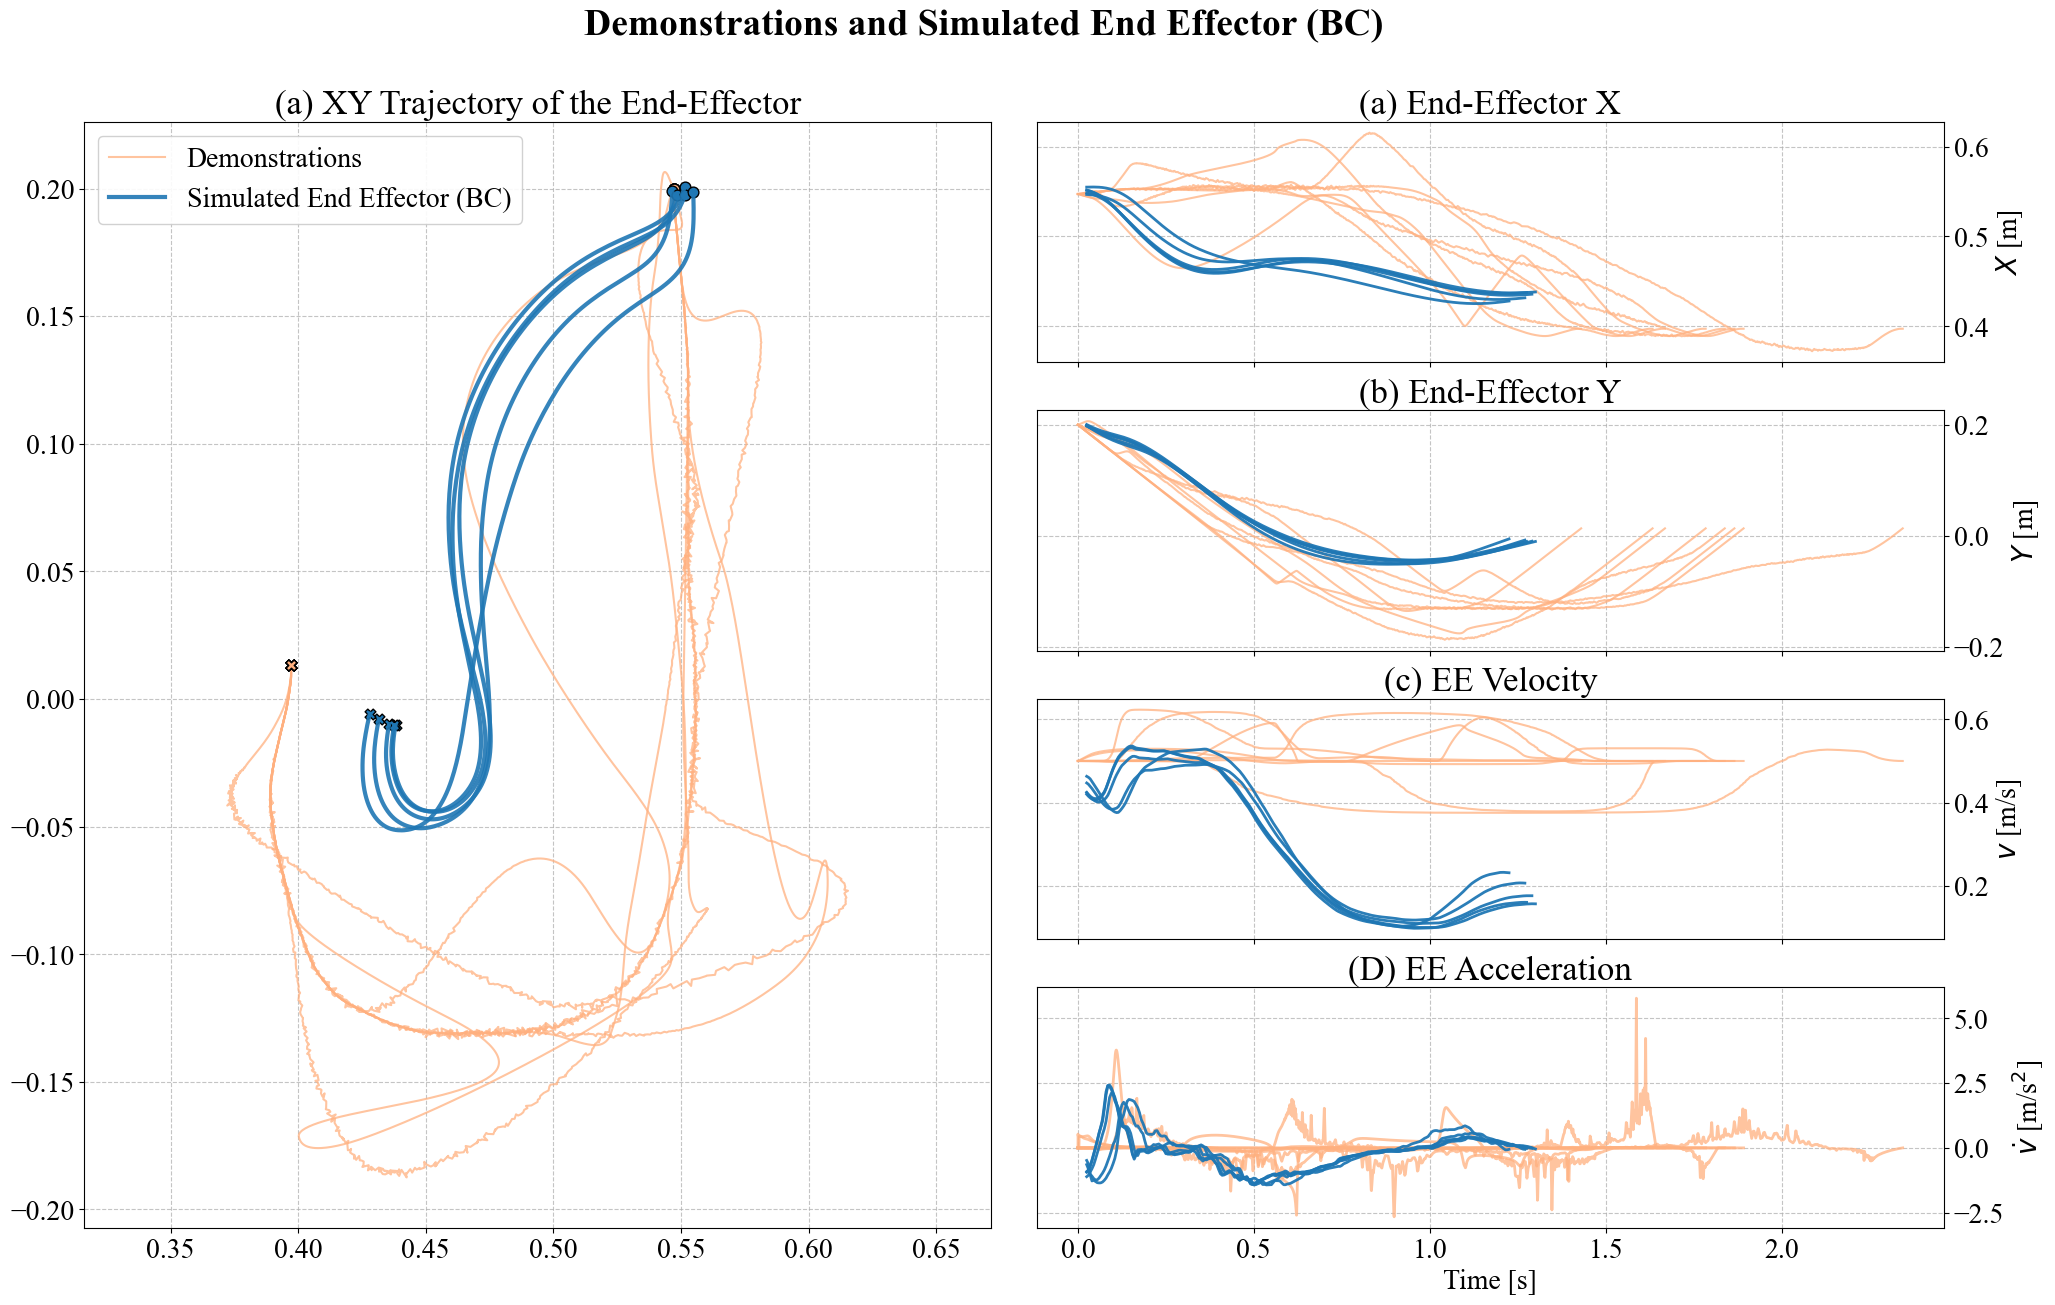

In [12]:
plot_trajectory_data(
    TDList_learnt=TDList_Learnt, 
    plot_state_dot_indices=[3],
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations",
    TD_learnt_name="Simulated End Effector (BC)", 
    filedate=f"{FILEDATE}_BC"
)

# Save Trajectory Data

In [13]:
save_traj_data(
    TDList=TDList_Learnt, 
    filepath=join("data_dummy", f"TDList_Learnt_{FILEDATE}_BC.pkl")
)

[INFO]: Trajectory Data saved succesfully -> data_dummy\TDList_Learnt_J_BC.pkl
